In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import lightgbm
from lightgbm import LGBMRegressor
import sklearn
from sklearn.linear_model import LinearRegression

In [6]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

statsmodels: 0.14.2
pandas     : 2.2.2
seaborn    : 0.13.2
numpy      : 1.26.4
sklearn    : 1.5.1
matplotlib : 3.9.2
lightgbm   : 4.6.0



In [7]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais\Dados/vendas_imoveis.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\conta\AppData\Local\Temp\ipykernel_6480\3779393279.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais\Dados/vendas_imoveis.csv')


In [8]:
df.head()

,data_venda,preco,tipo_imovel,numero_quartos
0,2011-02-07 0:00,525000,casa,4
1,2011-02-27 0:00,290000,casa,3
2,2011-03-07 0:00,328000,casa,3
3,2011-03-09 0:00,380000,casa,4
4,2011-03-21 0:00,310000,casa,3


In [9]:
df.shape

(29580, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   data_venda      29580 non-null  object
 1   preco           29580 non-null  int64 
 2   tipo_imovel     29580 non-null  object
 3   numero_quartos  29580 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 924.5+ KB


In [11]:
df.index = pd.to_datetime(df.data_venda)
df = df.drop(columns = ['data_venda'])

In [12]:
df.head()

,preco,tipo_imovel,numero_quartos
data_venda,,,
2011-02-07,525000,casa,4
2011-02-27,290000,casa,3
2011-03-07,328000,casa,3
2011-03-09,380000,casa,4
2011-03-21,310000,casa,3


In [13]:
print(f'Valor-p da Coluna de Número de Quarto: {adfuller(df.numero_quartos)[1]}')

Valor-p da Coluna de Número de Quarto: 0.004638291435419081


In [14]:
print(f'Valor da Coluna de Preço: {adfuller(df.preco)[1]}')

Valor da Coluna de Preço: 1.5745251680571497e-18


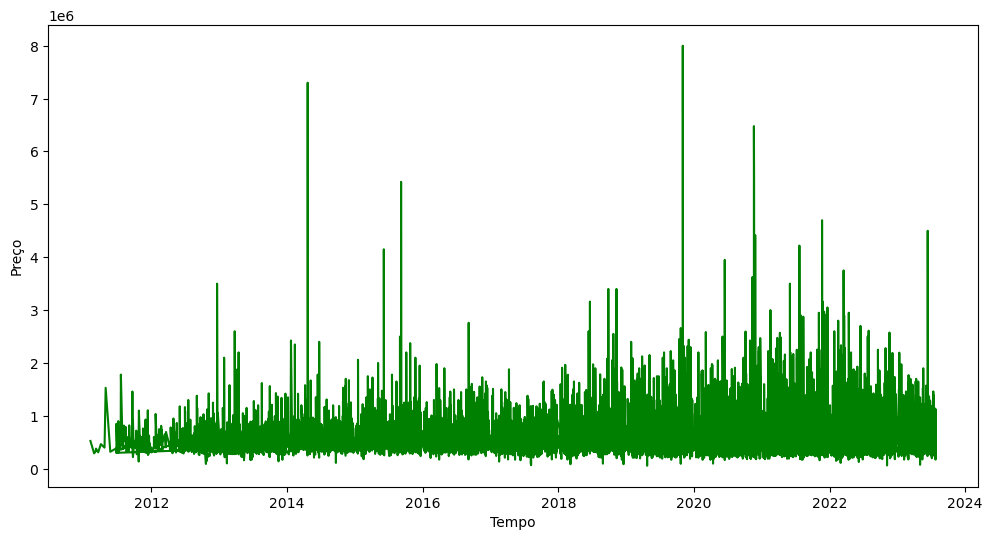

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['preco'], color = 'green')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.show()

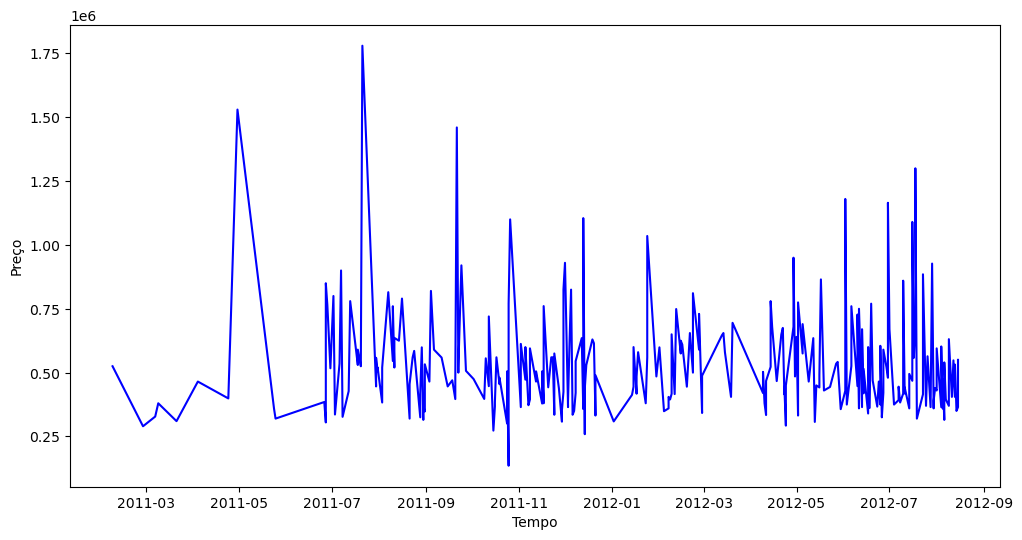

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['preco'][:300], color = 'blue')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.show()

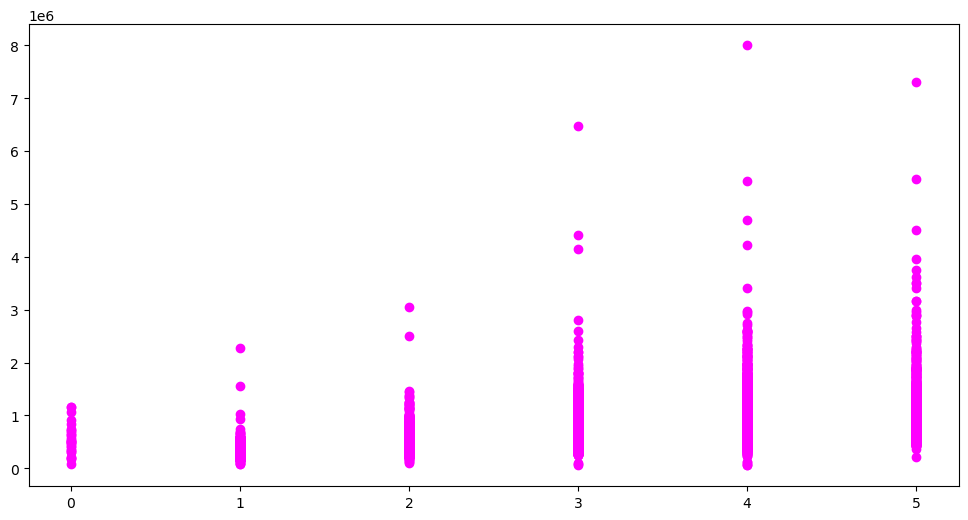

In [17]:
plt.figure(figsize=(12, 6))
plt.scatter(df['numero_quartos'], df['preco'], color = 'magenta')
plt.show()

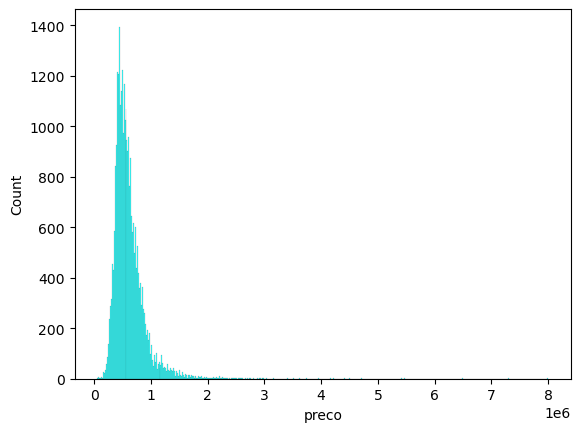

In [18]:
sns.histplot(df['preco'], color = 'cyan')
plt.show()

In [19]:
df['preco'] = np.log(df['preco'])

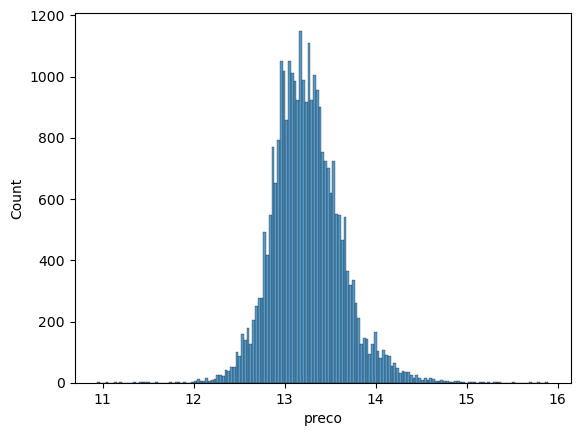

In [20]:
sns.histplot(df['preco'])
plt.show()

In [21]:
df.head()

,preco,tipo_imovel,numero_quartos
data_venda,,,
2011-02-07,13.171154,casa,4
2011-02-27,12.577636,casa,3
2011-03-07,12.700769,casa,3
2011-03-09,12.847927,casa,4
2011-03-21,12.644328,casa,3


In [22]:
df['tipo_imovel'] = LabelEncoder().fit_transform(df['tipo_imovel'])

In [23]:
df = df.resample('m').mean()

C:\Users\conta\AppData\Local\Temp\ipykernel_6480\3790088110.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('m').mean()


In [24]:
df.head()

,preco,tipo_imovel,numero_quartos
data_venda,,,
2011-02-28,12.874395,1.000000,3.500000
2011-03-31,12.731008,1.000000,3.333333
2011-04-30,13.395763,1.000000,3.666667
2011-05-31,12.733577,1.000000,3.000000
2011-06-30,13.076171,0.833333,3.333333


In [25]:
df.drop('tipo_imovel', axis = 1, inplace=True) 

In [26]:
for i in range(len(df['numero_quartos'])):
    df['numero_quartos'][i] = np.round(df['numero_quartos'][i])

C:\Users\conta\AppData\Local\Temp\ipykernel_6480\1541167566.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['numero_quartos'][i] = np.round(df['numero_quartos'][i])
C:\Users\conta\AppData\Local\Temp\ipykernel_6480\1541167566.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to pe

In [27]:
df =df.dropna()

In [28]:
df.head()

,preco,numero_quartos
data_venda,,
2011-02-28,12.874395,4.0
2011-03-31,12.731008,3.0
2011-04-30,13.395763,4.0
2011-05-31,12.733577,3.0
2011-06-30,13.076171,3.0


In [29]:
df.tail()

,preco,numero_quartos
data_venda,,
2023-03-31,13.311664,3.0
2023-04-30,13.314660,3.0
2023-05-31,13.303070,3.0
2023-06-30,13.371549,3.0
2023-07-31,13.218317,3.0


In [30]:
resultado = seasonal_decompose(df['preco']) 

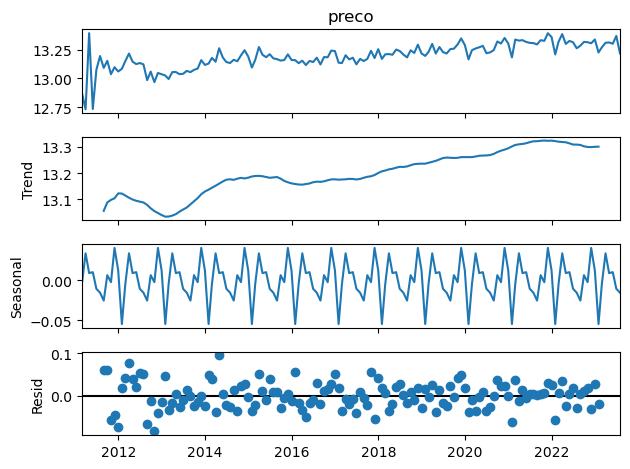

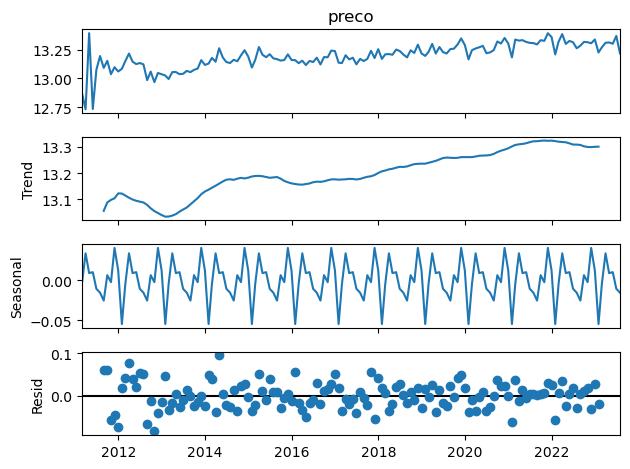

In [31]:
resultado.plot()

<Axes: xlabel='data_venda'>

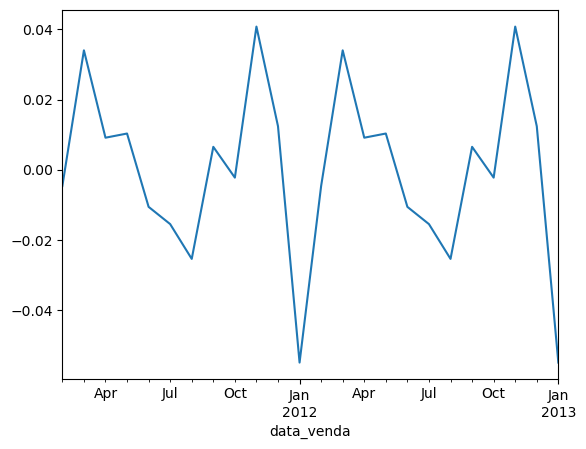

In [32]:
resultado.seasonal[:24].plot()

In [33]:
df['ano'] = df.index.year
df['mes'] = df.index.month

In [34]:
df.head()

,preco,numero_quartos,ano,mes
data_venda,,,,
2011-02-28,12.874395,4.0,2011,2
2011-03-31,12.731008,3.0,2011,3
2011-04-30,13.395763,4.0,2011,4
2011-05-31,12.733577,3.0,2011,5
2011-06-30,13.076171,3.0,2011,6


In [35]:
indice = int(len(df) *.7)

In [36]:
print(len(df), indice)

150 105


In [37]:
dados_treino = df.iloc[:indice]

In [38]:
dados_treino.tail(1)

,preco,numero_quartos,ano,mes
data_venda,,,,
2019-10-31,13.296874,3.0,2019,10


In [39]:
dados_teste = df.iloc[indice:]

In [40]:
dados_teste.head(1)

,preco,numero_quartos,ano,mes
data_venda,,,,
2019-11-30,13.349959,3.0,2019,11


In [41]:
dados_entrada_treino = dados_treino.drop(columns = ['preco'])

In [42]:
dados_saida_treino = dados_treino[['preco']]

In [43]:
modelo_v1 = LGBMRegressor()

In [44]:
modelo_v1.fit(dados_entrada_treino, dados_saida_treino)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23
[LightGBM] [Info] Number of data points in the train set: 105, number of used features: 2
[LightGBM] [Info] Start training from score 13.151420
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


LGBMRegressor()

In [45]:
dados_entrada_teste = dados_teste.drop(columns = ['preco'])
dados_saida_teste = dados_teste[['preco']]

In [46]:
previsoes_v1 = modelo_v1.predict(dados_entrada_teste)

In [47]:
previsoes_v1 = np.exp(previsoes_v1)

In [48]:
dados_saida_teste = np.exp(dados_saida_teste)

In [49]:
print(mean_absolute_error(dados_saida_teste, previsoes_v1))

41083.66076755184


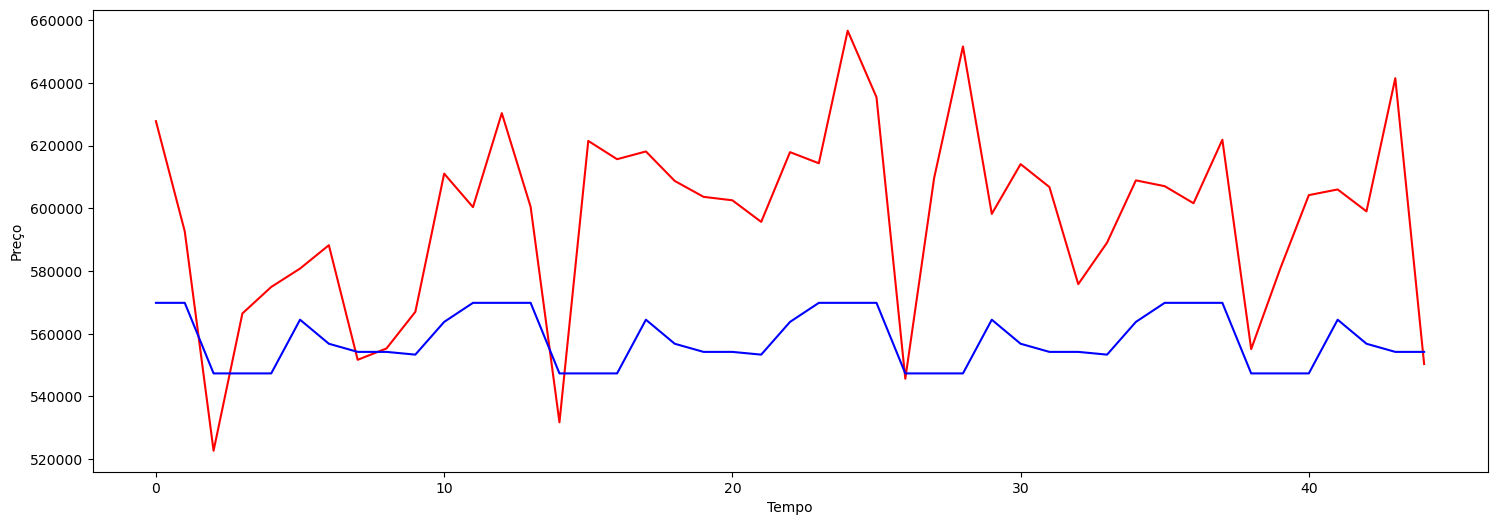

In [50]:
plt.figure(figsize = (18,6))
plt.plot(np.array(dados_saida_teste), color = 'red')
plt.plot(np.array(previsoes_v1), color = 'blue')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.show()

In [51]:
modelo_v2 = LinearRegression()

In [52]:
modelo_v2.fit(dados_entrada_treino, dados_saida_treino)

LinearRegression()

In [53]:
dados_entrada_teste = dados_teste.drop(columns = ['preco'])
dados_saida_teste = dados_teste[['preco']]

In [ ]:
previsoes_v2 = modelo_v2.predict(dados_entrada_teste)

In [55]:
previsoes_v2 = np.exp(previsoes_v2)

In [56]:
dados_saida_teste = np.exp(dados_saida_teste)

In [57]:
print(mean_absolute_error(dados_saida_teste, previsoes_v2))

22987.624211615937


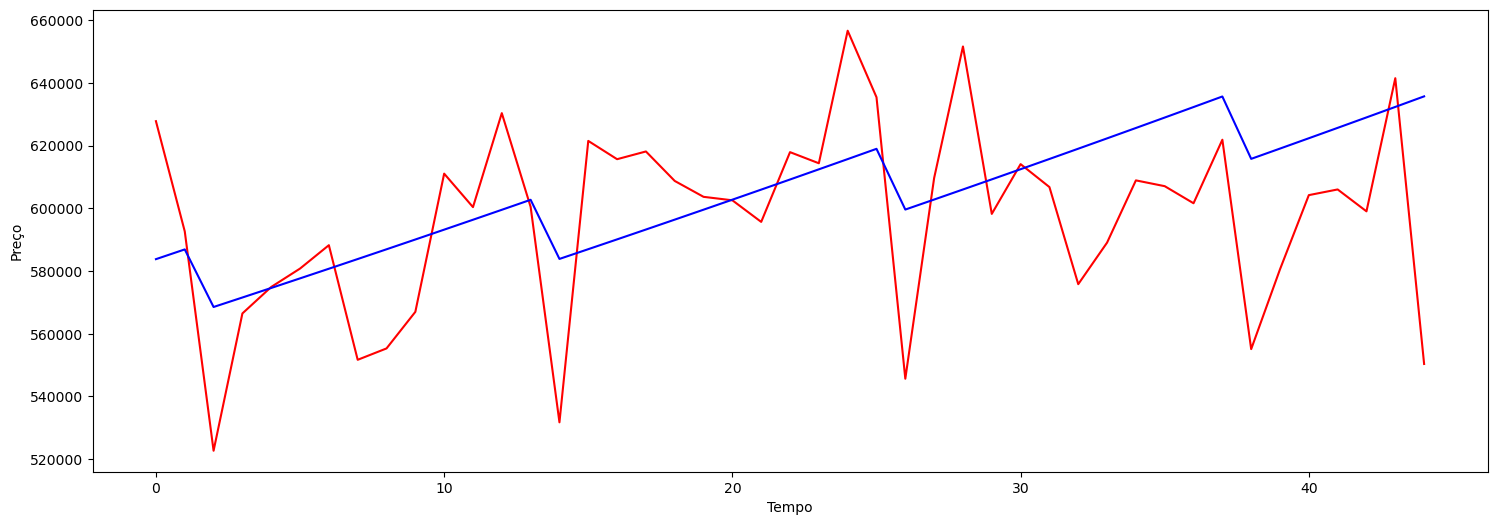

In [58]:
plt.figure(figsize = (18,6))
plt.plot(np.array(dados_saida_teste), color = 'red')
plt.plot(np.array(previsoes_v2), color = 'blue')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.show()

In [69]:
import joblib
filename = 'C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/part5/modelo_v2.sav'
joblib.dump(modelo_v2, filename)

['C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/part5/modelo_v2.sav']

In [64]:
novos_dados = {
    'numero_quartos': [4.0],
    'ano': [2023],
    'mes': [8]
}

In [63]:
data_index = pd.to_datetime(['2023-08-01'])

In [67]:
df_novo_dados = pd.DataFrame(novos_dados, index = [data_index])

In [68]:
df_novo_dados.head()

,numero_quartos,ano,mes
2023-08-01,4.0,2023,8


In [71]:
modelo_final = joblib.load(filename)

In [73]:
previsao_preco = modelo_final.predict(df_novo_dados)

In [75]:
previsao_preco

array([[13.46746194]])

In [76]:
previsao_preco = np.exp(previsao_preco)

In [77]:
previsao_preco

array([[706064.55013595]])

In [ ]:
print(f'Previsão do preço do imovél: {previsao_preco} ')

Previsão do preço do imovél: [[706064.55013595]]
